In [1]:
import pandas as pd
from model_processor import ModelProcessor
import warnings
warnings.filterwarnings('ignore')

In [2]:
source_df = pd.read_json("https://doctorat.dragulin.net/api/DateModelare/prognoza?tipValoare=VenitTotal&anInceput=2016&anSfarsit=2025", orient='records')
indicatori_df = pd.read_json("https://doctorat.dragulin.net/api/DateModelare/indicatori-total?anInceput=2016&anSfarsit=2025", orient='records')

In [3]:
source_df[source_df['Data'] >= '2025-01-01']

,Data,Valoare
106,2025-01-01T00:00:00,530278.05
107,2025-02-01T00:00:00,1507947.47
108,2025-03-01T00:00:00,1073265.29
109,2025-04-01T00:00:00,1209356.71
110,2025-05-01T00:00:00,1453453.13
111,2025-06-01T00:00:00,1028772.96
112,2025-07-01T00:00:00,705898.41
113,2025-08-01T00:00:00,719827.04
114,2025-09-01T00:00:00,699739.52
115,2025-10-01T00:00:00,3127153.98


### Facem join intre cele doua dataseturi

In [4]:
serie_df = pd.merge(
  source_df,
  indicatori_df.rename(columns={'Data': 'data_indicatori'}),
  how='left',
  left_on='Data',
  right_on='data_indicatori'
).drop(columns=['data_indicatori'])

In [5]:
serie_df = serie_df.rename(columns={'Valoare': 'Income'})

### Initializam clasa care proceseaza modelul

In [6]:
procesor = ModelProcessor(serie_df, 'Total Revenues (Income)', target_col='income')

### Rulam anliza asupra datelor

<Figure size 1600x800 with 0 Axes>

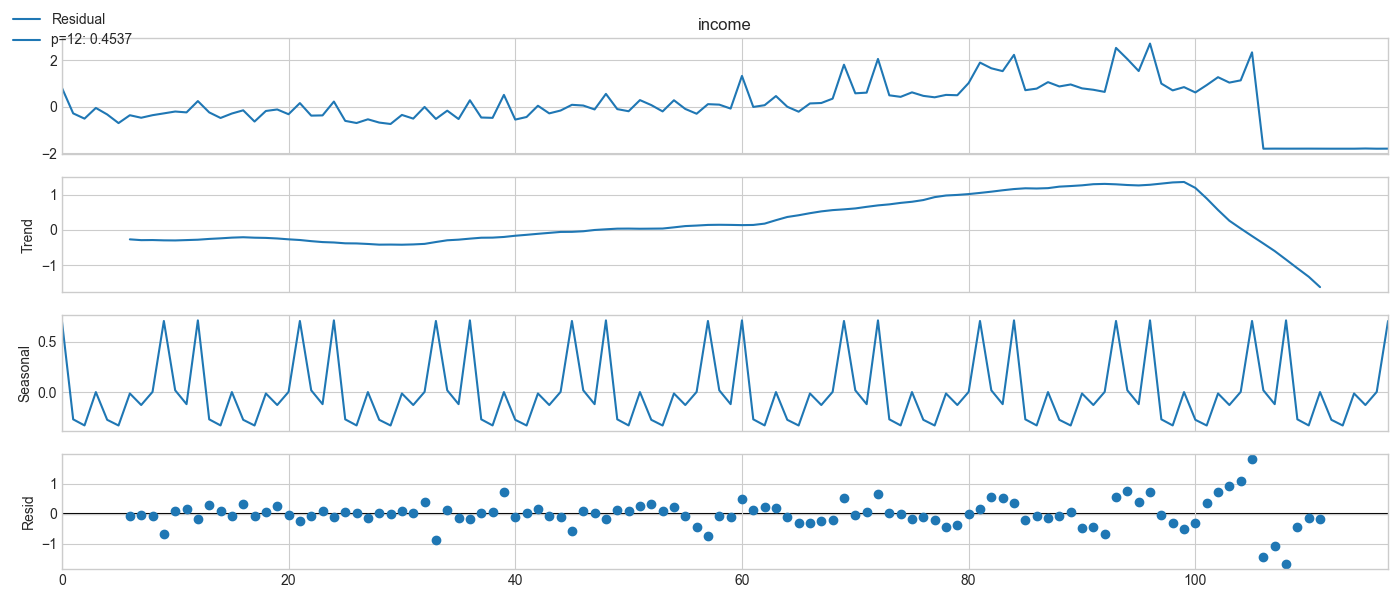

<Figure size 1000x400 with 0 Axes>

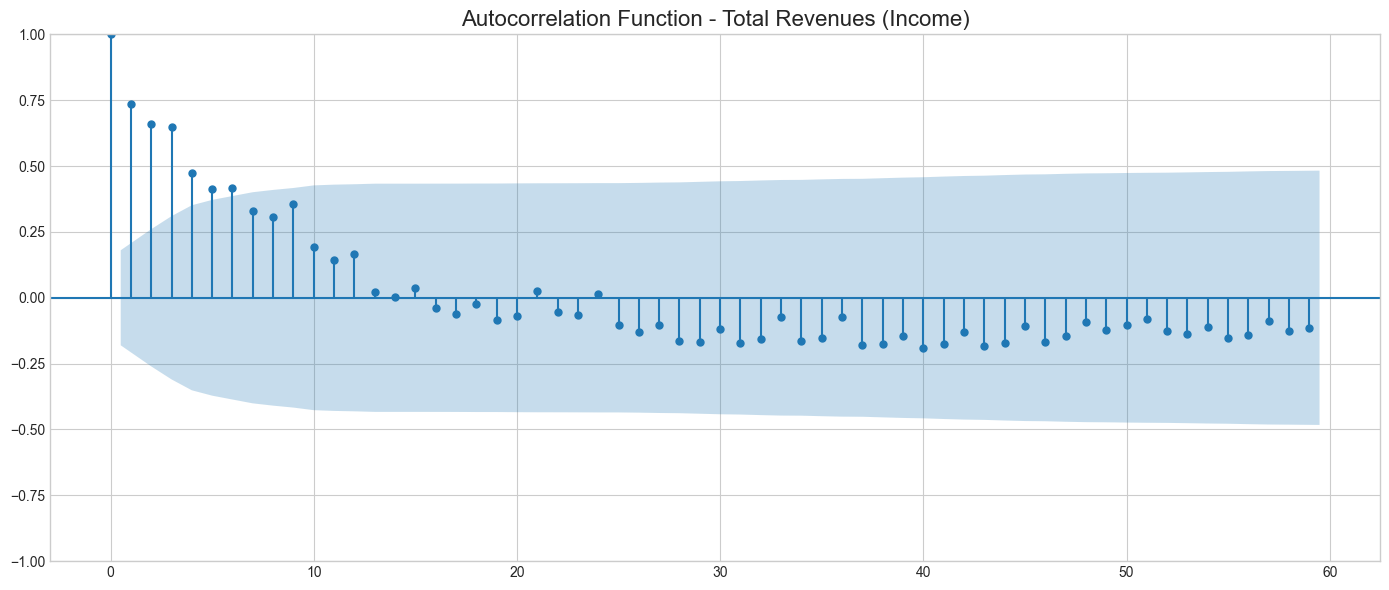

<Figure size 1000x400 with 0 Axes>

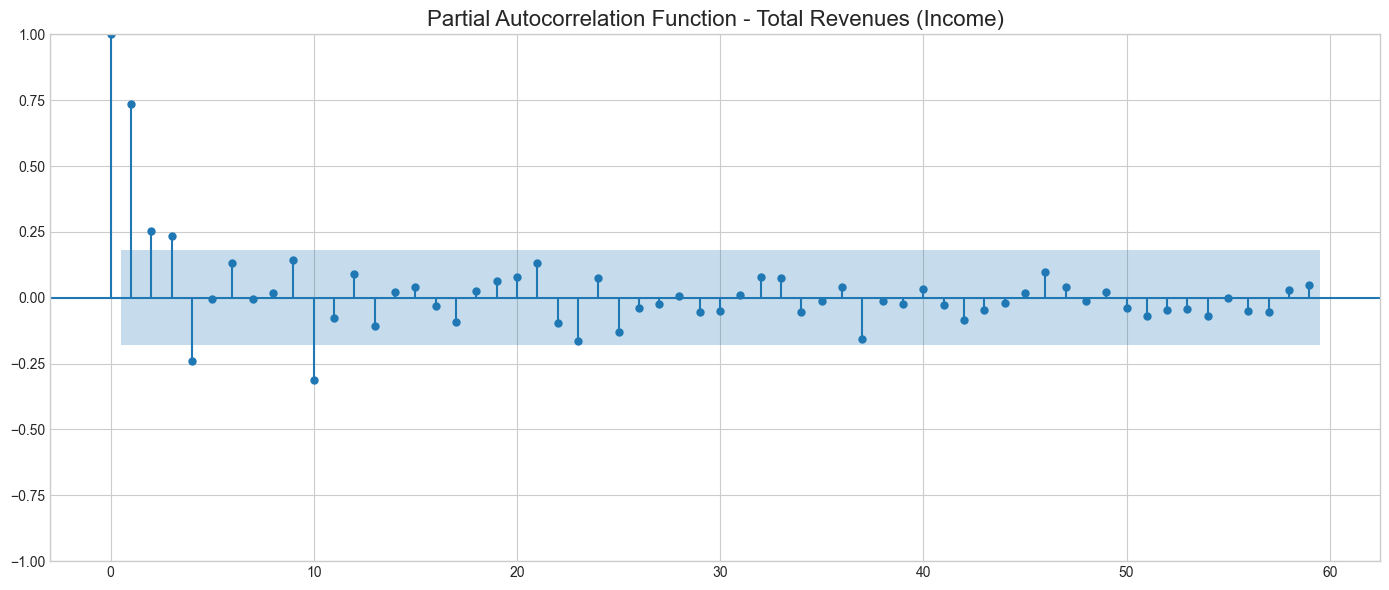

Optimal seasonality period: 12
Residual std dev: 0.4537
The largest ACF coefficient (excluding lag 0) is at lag 1: 0.736
The largest PACF coefficient (excluding lag 0) is at lag 1: 0.742
The series shows strong autocorrelation at the first lag (possible AR or MA process).
The series shows strong partial autocorrelation at the first lag (possible AR process).


In [7]:
procesor.analyze()

### Rulam toate modelele

In [8]:
from models import ToateModelele
procesor.run_all_models(ToateModelele())

Importing plotly failed. Interactive plots will not work.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step


...

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step


00:21:17 - cmdstanpy - INFO - Chain [1] start processing


00:21:18 - cmdstanpy - INFO - Chain [1] done processing


### Afisam rezultatele


UNIVARIATE
                          model        r2      rmse        mape
0                Univariate GRU  0.406646  1.267113   59.191180
1                Univariate TCN  0.177678  1.491693   63.454089
2  Univariate Linear Regression -0.148295  1.762728  107.499462
3               Univariate LSTM -0.376073  1.929653   89.651782
4     Univariate Seasonal Naive -0.770569  2.188845   94.739573
5                Univariate ETS -1.010482  2.332430  100.382946
6            Univariate Prophet -1.304380  2.497098  113.431548
7             Univariate SARIMA -1.607459  2.656240  116.635904


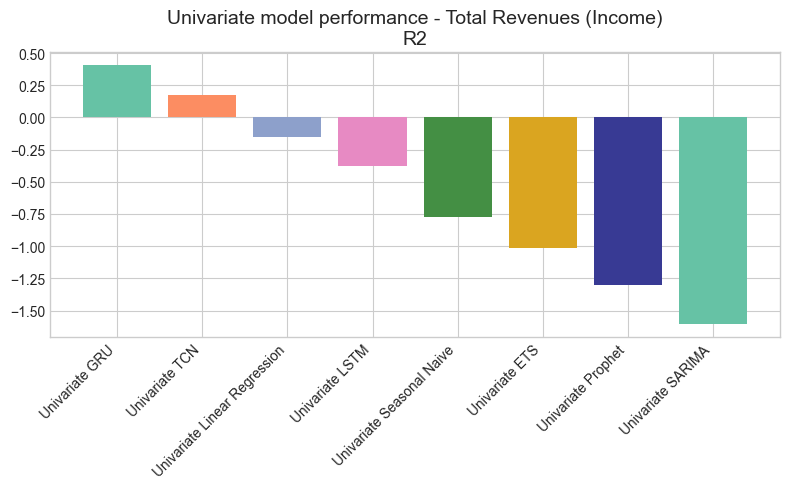

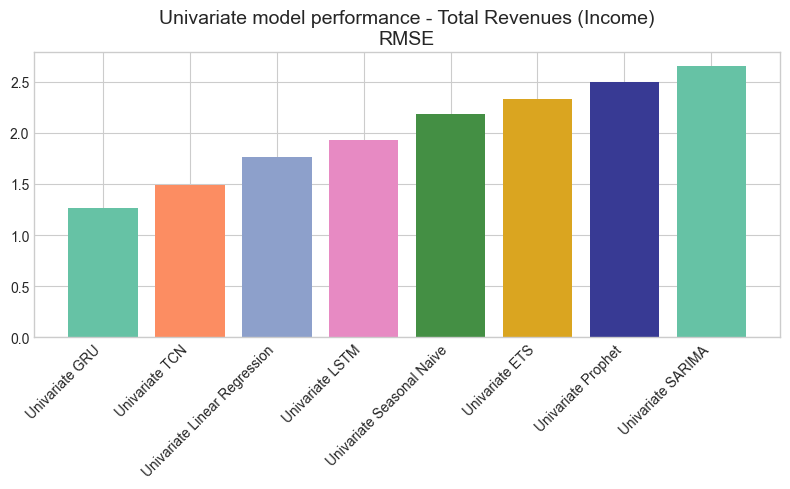

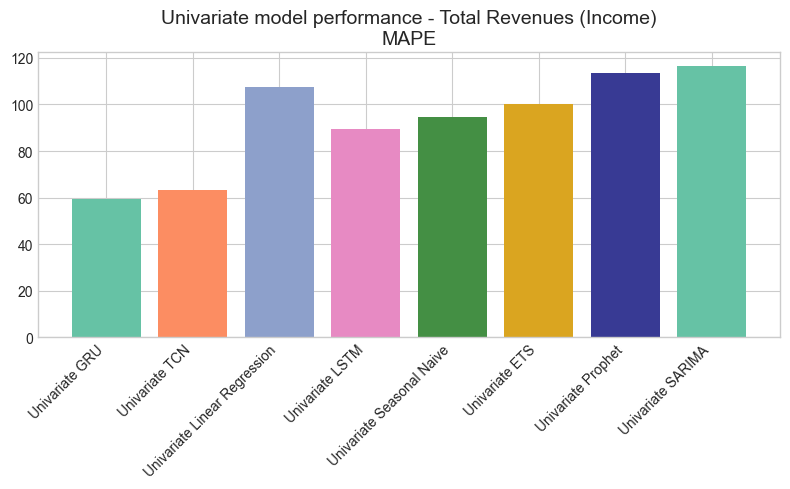


MULTIVARIATE
                            model        r2      rmse        mape
0               Multivariate LSTM -0.854556  2.240157  103.406673
1                Multivariate ECM -0.969969  2.308810  112.636980
2                Multivariate VAR -0.974074  2.311214  108.710359
3                Multivariate GRU -1.160785  2.418045  112.913786
4  Multivariate Linear Regression -1.291374  2.490041  120.304803
5                Multivariate TCN -1.832409  2.768449  133.283217
6             Multivariate SARIMA -2.143281  2.916420  124.431519


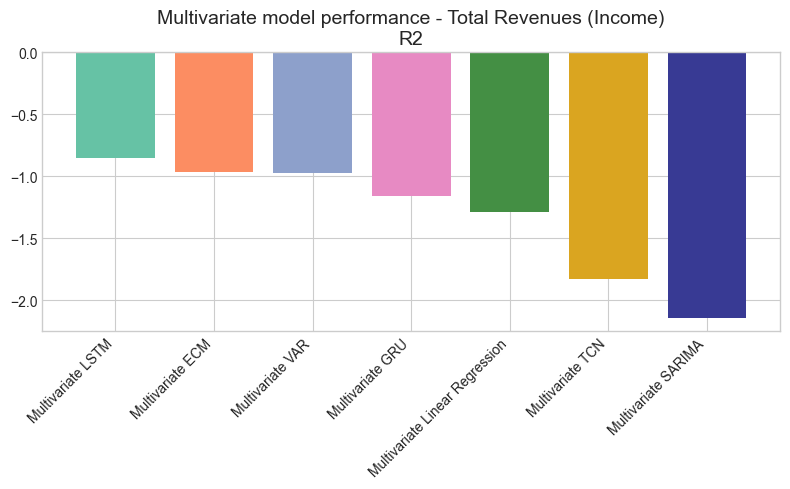

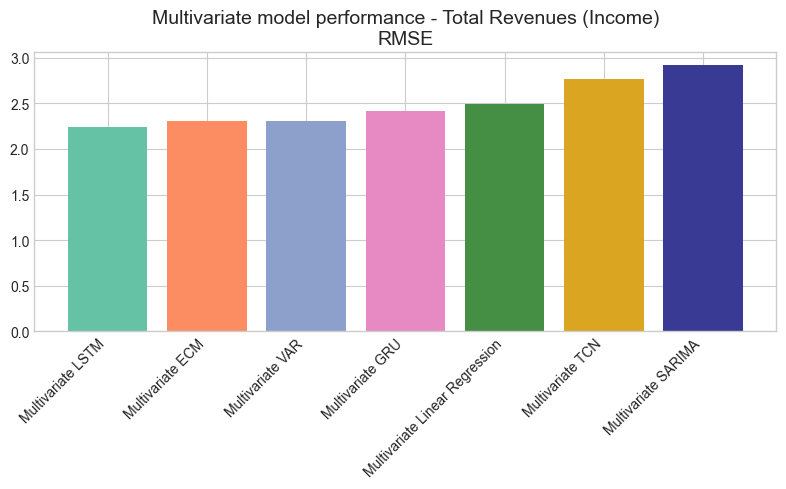

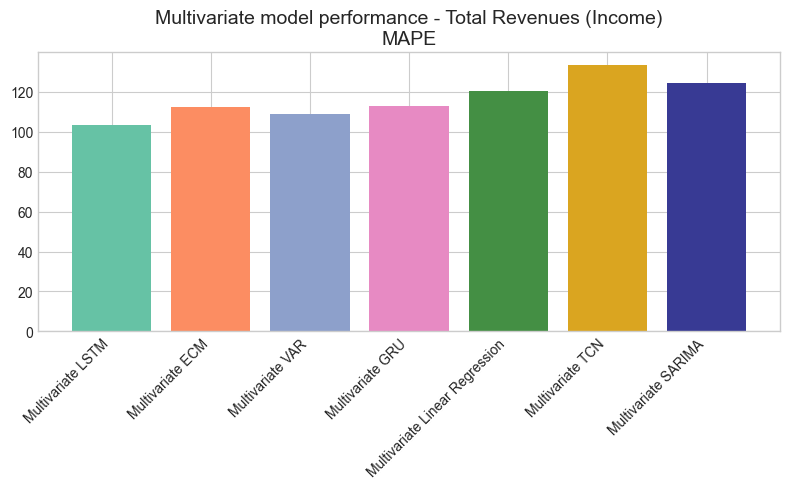

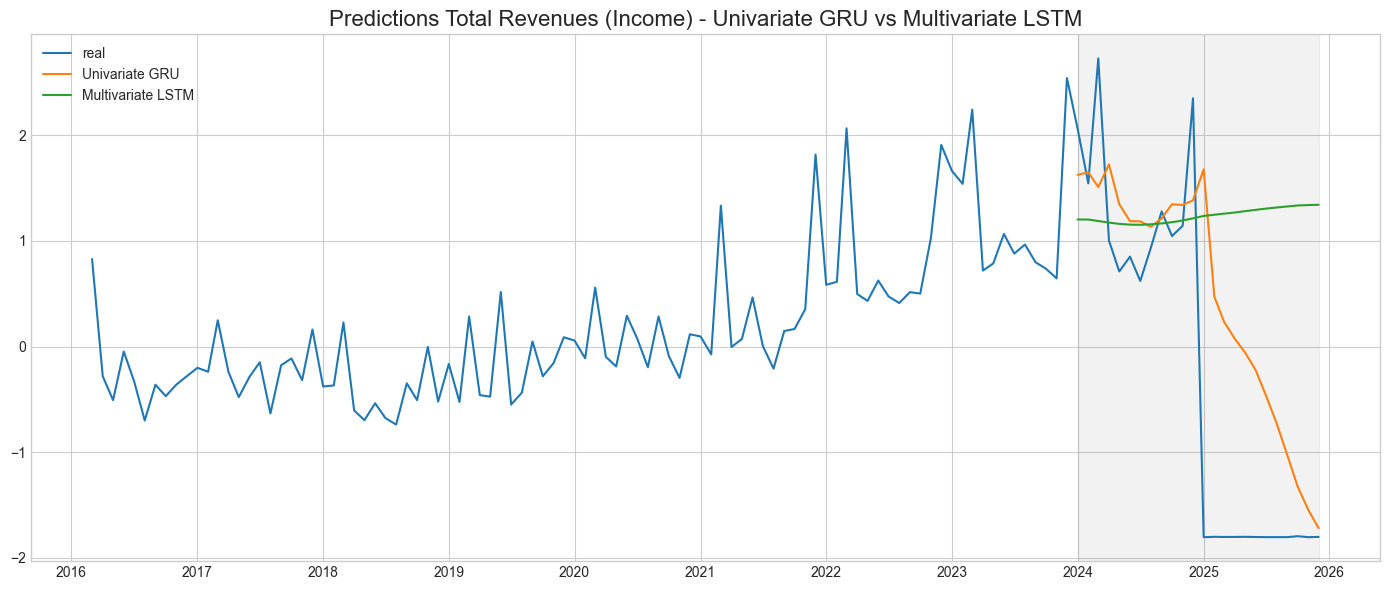

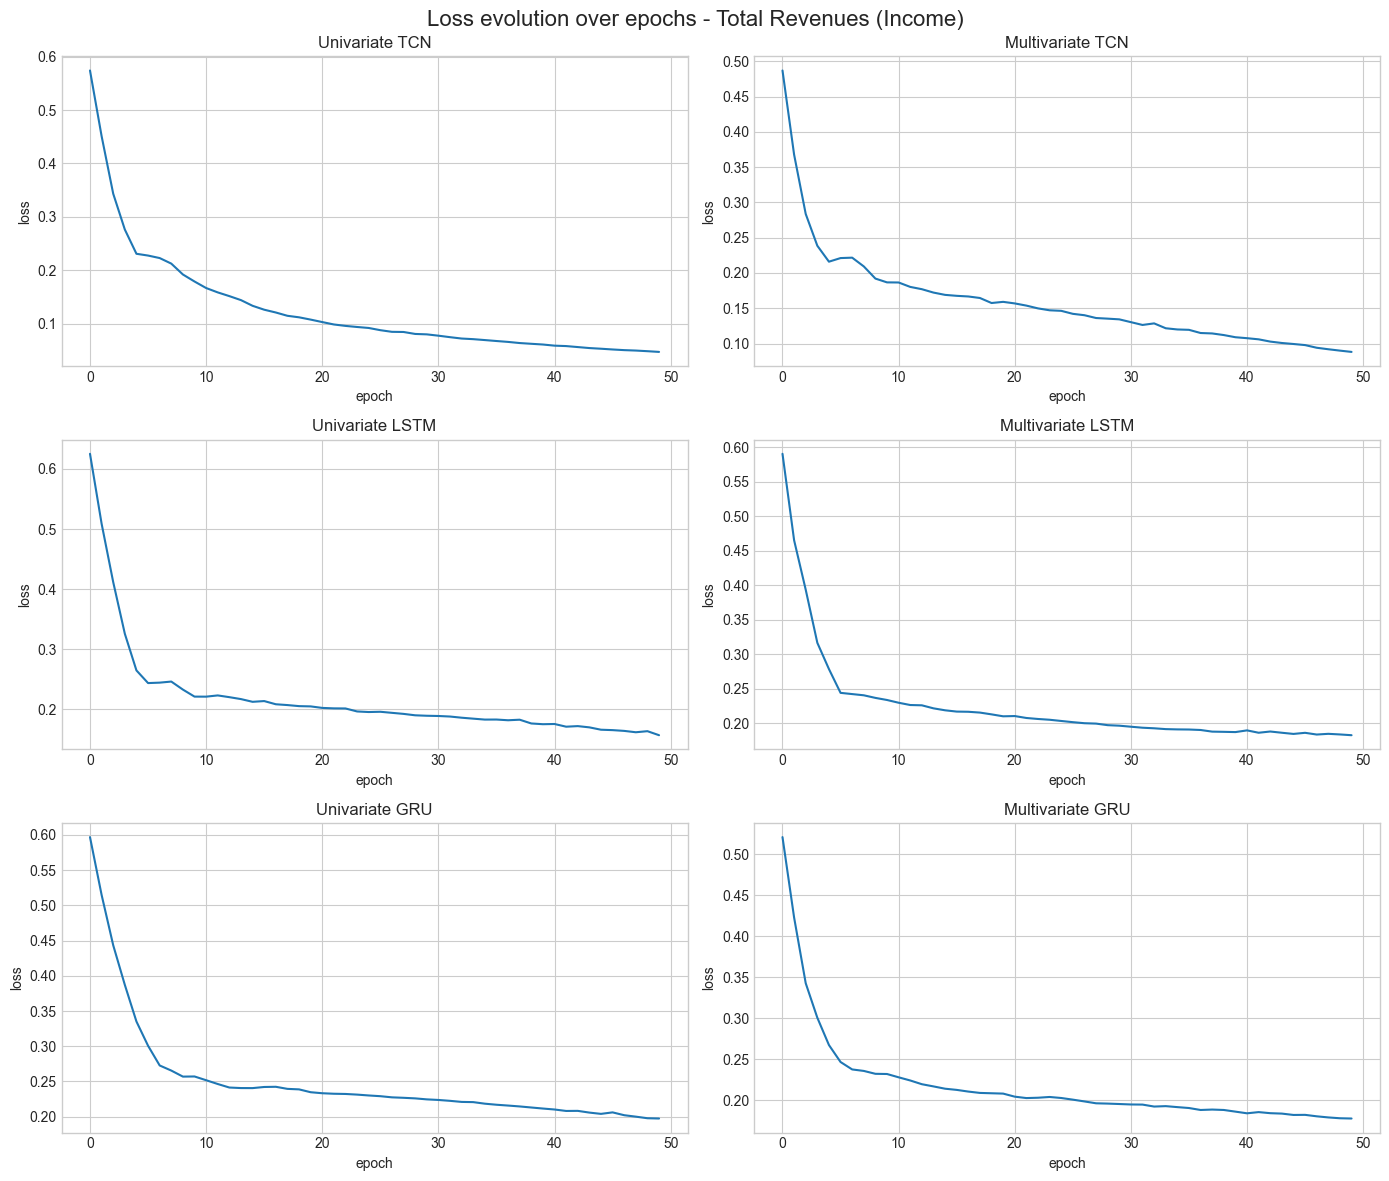

In [9]:
procesor.process_results()